In [1]:
%load_ext autoreload
%autoreload 2

import jax.numpy as jnp

from trunx.gp3.parameter_estimation import run_full_analysis
from trunx.gp3.PG3_model_impl import prepare_data

/Users/glory/Documents/Research/TrunkX/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running HMC inference for 3PG model (DBH)
Number of species: 1
Number of observations: 11
Warmup samples: 200
Posterior samples: 200
Number of chains: 2
------------------------------------------------------------


/Users/glory/Documents/Research/TrunkX/src/trunx/gp3/parameter_estimation.py:165: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 400/400 [00:29<00:00, 13.36it/s, 30 steps of size 1.42e-01. acc. prob=0.95]



MCMC Summary

                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  CoeffCond      0.04      0.01      0.03      0.01      0.06    282.84      1.00
          Y      0.53      0.05      0.52      0.44      0.60    374.23      1.00
    alphaCx      0.17      0.04      0.16      0.11      0.22    129.93      1.02
    gammaF0      0.10      0.03      0.10      0.06      0.15    439.26      1.00
    gammaF1      0.44      0.09      0.43      0.29      0.58    217.44      1.01
  sigma_DBH      1.51      0.12      1.51      1.33      1.71    343.86      1.00
       tRho    506.52    101.55    499.73    364.68    661.55    235.78      1.01
    tgammaF     26.89     13.11     24.09     10.59     48.47    464.24      1.00

Number of divergences: 32

Convergence Diagnostics
R-hat values (should be < 1.1):
  ✓ CoeffCond: R-hat = 1.006, ESS = 306.7
  ✓ Y: R-hat = 1.018, ESS = 390.2
  ✓ alphaCx: R-hat = 1.023, ESS = 130.7
  ✓ gammaF0: R-hat = 1.012, ESS = 462.9
  ✓ gam

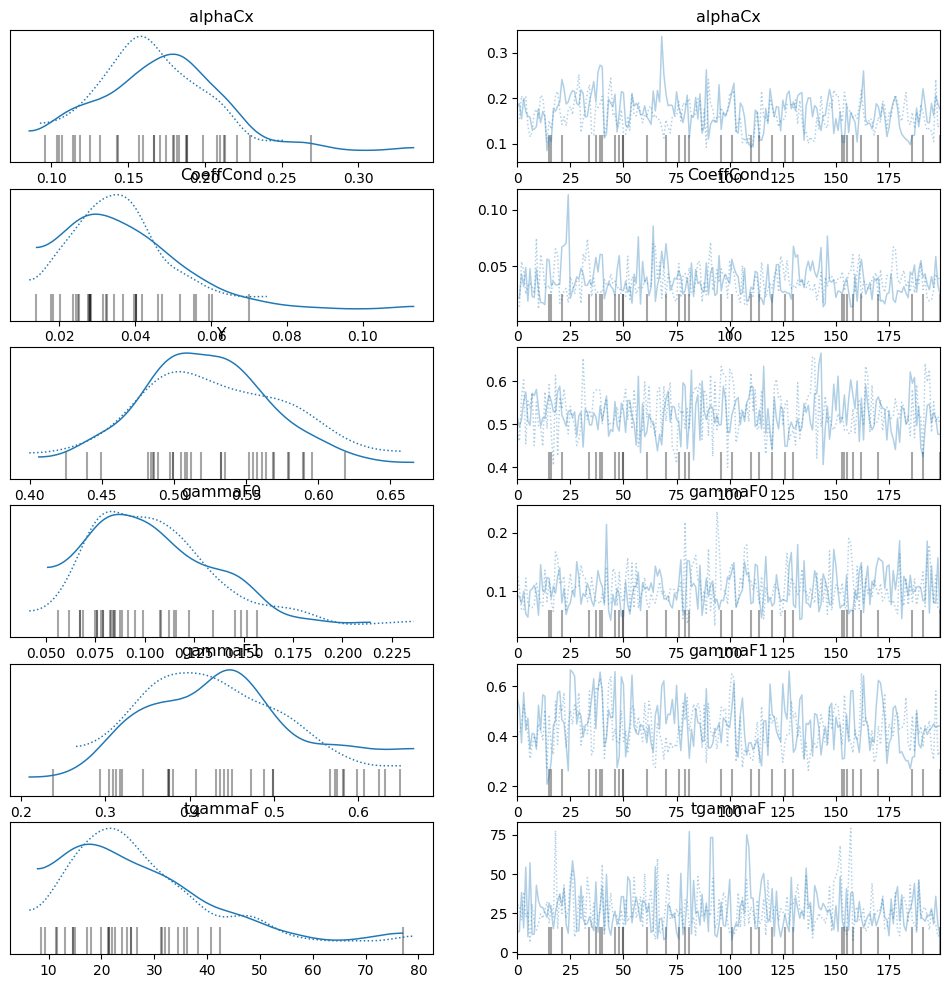

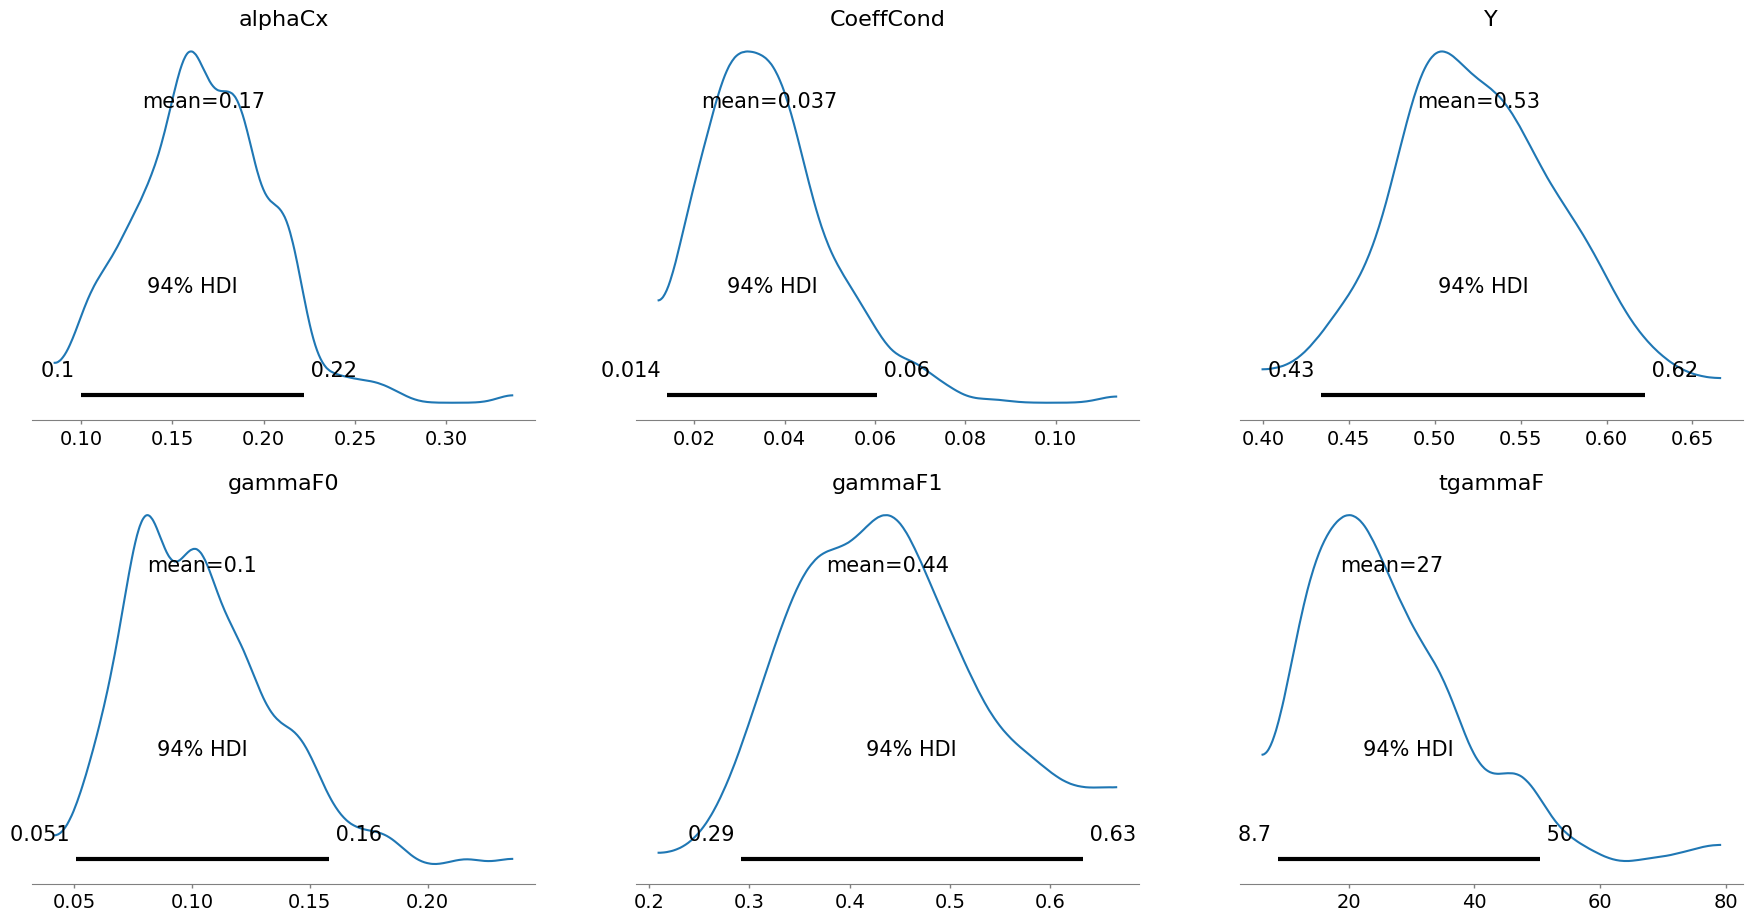

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alphaCx     0.167   0.036   0.100    0.222      0.003    0.002     131.0   
CoeffCond   0.037   0.014   0.014    0.060      0.001    0.001     307.0   
Y           0.525   0.050   0.434    0.622      0.003    0.002     390.0   
gammaF0     0.104   0.031   0.051    0.158      0.001    0.002     463.0   
gammaF1     0.438   0.092   0.291    0.632      0.006    0.004     213.0   
tgammaF    26.890  13.111   8.734   50.409      0.604    0.793     517.0   

           ess_tail  r_hat  
alphaCx       198.0   1.02  
CoeffCond     222.0   1.01  
Y             281.0   1.02  
gammaF0       300.0   1.01  
gammaF1       266.0   1.01  
tgammaF       308.0   1.01  


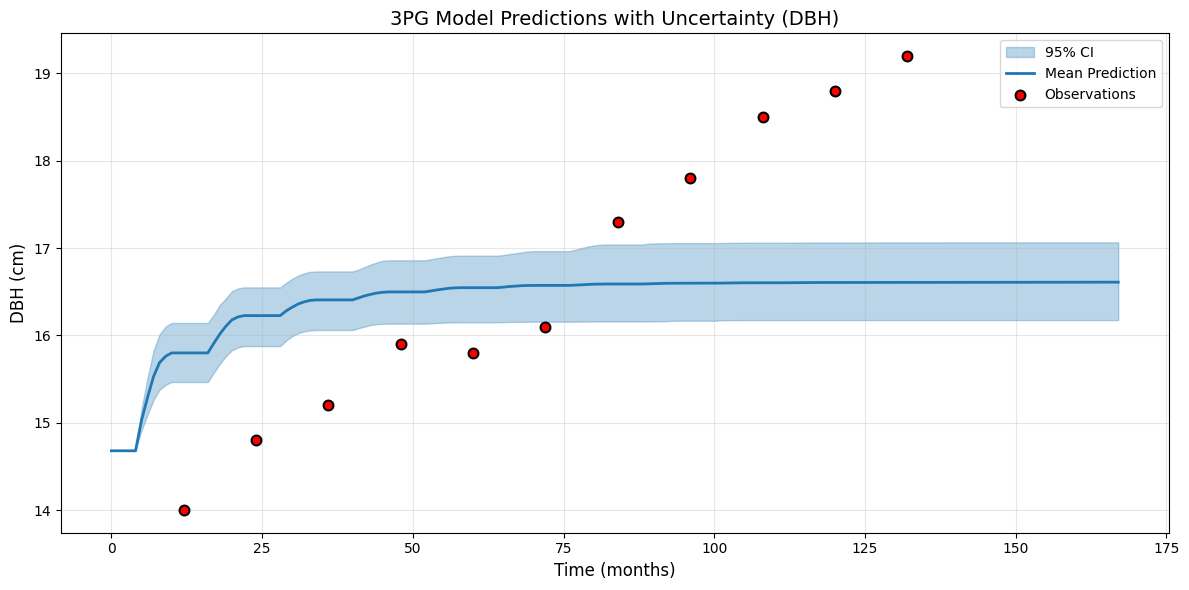

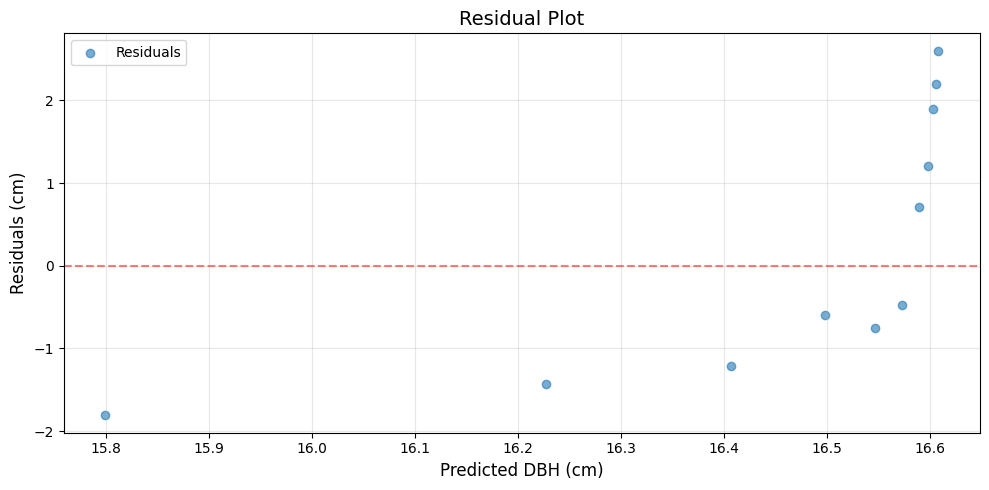

In [7]:
file_path = "./data/data_sspecies_nothinning.xlsx"

initial_state, climate, fixed_params, site_data, species_data, n_species = prepare_data(file_path)

# Dummy DBH observations (in cm)
obs_times = jnp.array([12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132])
obs_DBH = jnp.array([14, 14.8, 15.2, 15.9, 15.8, 16.1, 17.3, 17.8, 18.5, 18.8, 19.2])

# obs_times = jnp.asarray(pl.read_excel(file_path, sheet_name="observed")["idx"])
# obs_DBH = jnp.asarray(pl.read_excel(file_path, sheet_name="observed")["DBH"])

# Run analysis (with small number of samples for demonstration)
mcmc, samples, diagnostics = run_full_analysis(
    initial_state=initial_state,
    climate=climate,
    site=site_data,
    species=species_data,
    n_species=n_species,
    obs_DBH=obs_DBH,
    obs_times=obs_times,
    fixed_params=fixed_params,
    num_warmup=200,  # Small for demo
    num_samples=200,  # Small for demo
    num_chains=2,  # Small for demo
    output_dir="hmc_results_demo",
    show_plots=True,
)

In [5]:
import arviz as az

In [6]:
az.__version__

'0.23.4'